# 06. Comparación de los modelos

Para poder elegir el mejor modelo entre los tres que hemos usado (MobileNetV2, ResNet50 y EfficientNetB0), se hará una comparación de los datos visualmente.

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg

# Modelos a comparar
MODELS = ['efficientnetb0', 'mobilenetv2', 'resnet50']
# Ruta de los datos
BASE_PATH = os.path.join('..', 'outputs')

histories = {}
test_results = {}


for model in MODELS:
    # Nombre de la carpeta
    folder_name = f"{model}_outputs"
    # Carpeta de metricas
    metrics_dir = os.path.join(BASE_PATH, folder_name, 'metrics')
    
    # Construccion de nombres de archivos
    history_filename = f"{model}_history.csv"
    summary_filename = f"{model}_summary_metrics.csv"
    
    # Rutas completas
    history_path = os.path.join(metrics_dir, history_filename)
    summary_path = os.path.join(metrics_dir, summary_filename)
    
    # Carga historial
    if os.path.exists(history_path):
        histories[model] = pd.read_csv(history_path)
        print(f"Cargado historial: {history_filename}")
    else:
        print(f"Advertencia: No se encontró {history_path}")
        
    # Carga metricas
    if os.path.exists(summary_path):
        test_results[model] = pd.read_csv(summary_path)
        print(f"Cargado resumen: {summary_filename}")
    else:
        print(f"Advertencia: No se encontró {summary_path}")

print("\nProceso de carga finalizado.")

c:\Users\Rocío\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.stats import gaussian_kde


Cargado historial: efficientnetb0_history.csv
Cargado resumen: efficientnetb0_summary_metrics.csv
Cargado historial: mobilenetv2_history.csv
Cargado resumen: mobilenetv2_summary_metrics.csv
Cargado historial: resnet50_history.csv
Cargado resumen: resnet50_summary_metrics.csv

Proceso de carga finalizado.


## Comparativa de Loss, Accuracy y Learning Rate

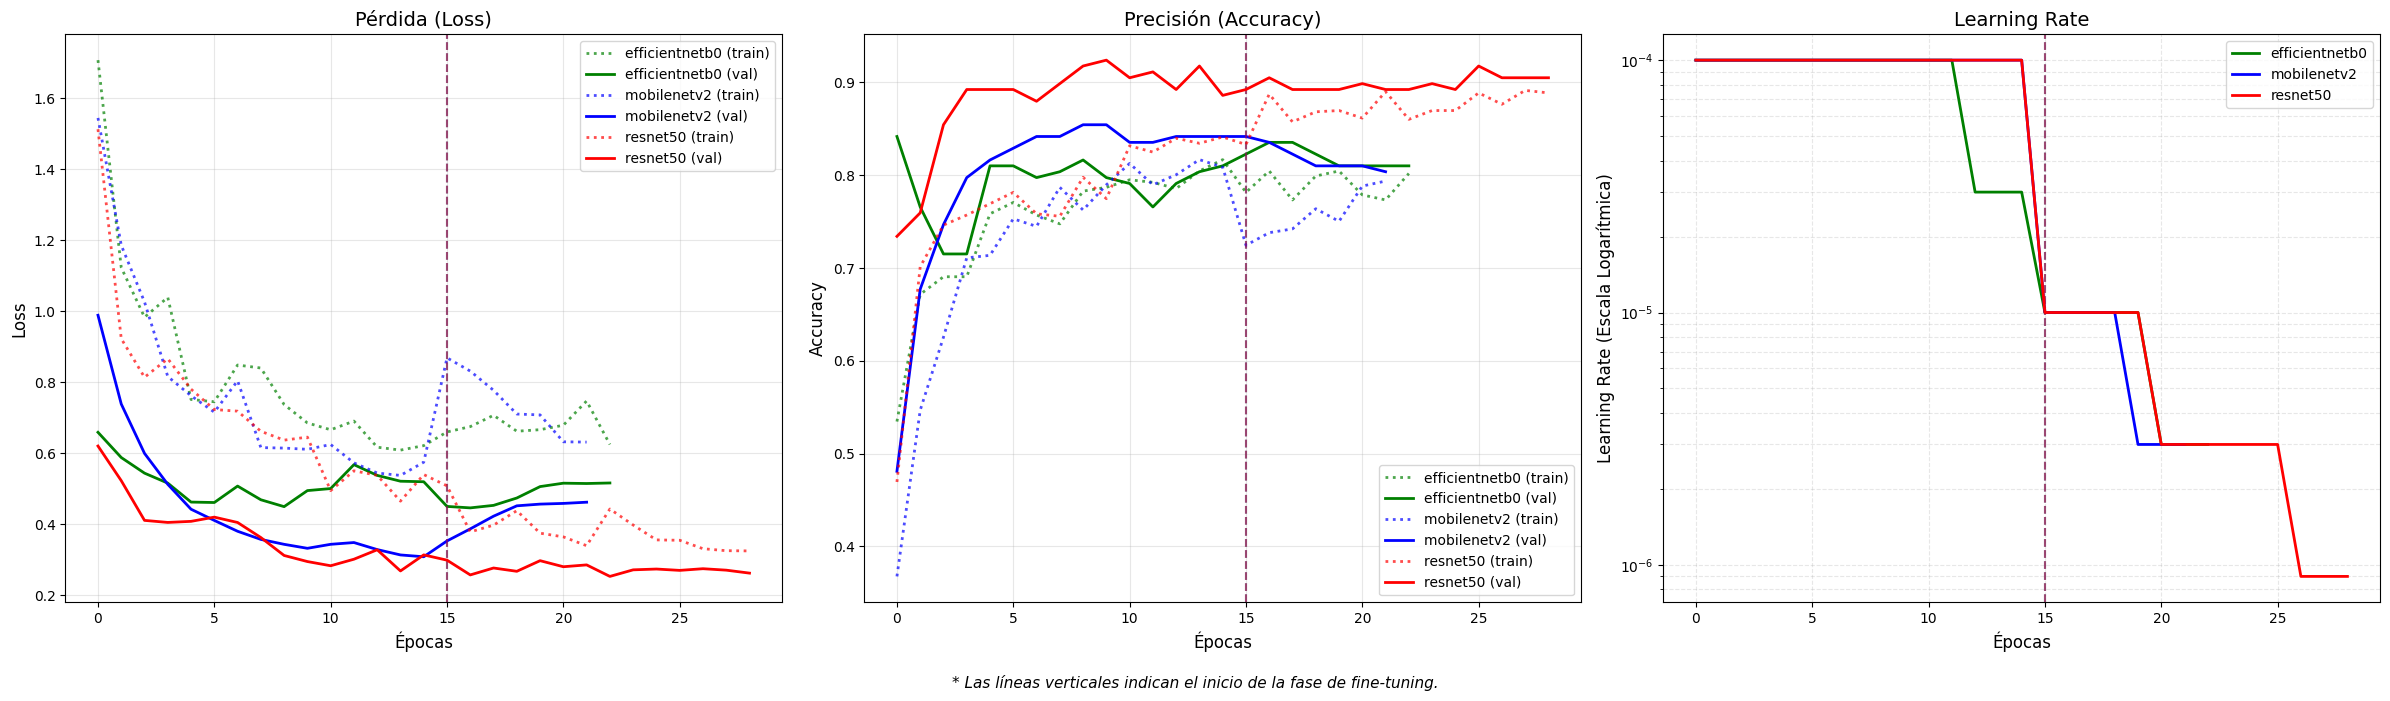

In [2]:
# 3 graficas
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 7))
colors = {'efficientnetb0': 'green', 'mobilenetv2': 'blue', 'resnet50': 'red'}

for model, df in histories.items():
    # Loss
    # Entrenamiento
    ax1.plot(df.index, df['loss'], label=f'{model} (train)', 
             color=colors[model], linestyle=':', alpha=0.7, linewidth=2)
    # Validacion
    ax1.plot(df.index, df['val_loss'], label=f'{model} (val)', 
             color=colors[model], linestyle='-', linewidth=2)

    # Accuracy
    ax2.plot(df.index, df['accuracy'], label=f'{model} (train)', 
             color=colors[model], linestyle=':', alpha=0.7, linewidth=2)
    ax2.plot(df.index, df['val_accuracy'], label=f'{model} (val)', 
             color=colors[model], linestyle='-', linewidth=2)

    # Learning rate
    if 'learning_rate' in df.columns:
        ax3.plot(df.index, df['learning_rate'], label=f'{model}', 
                 color=colors[model], linestyle='-', linewidth=2)

    # Inicio fine-tuning
    if 'phase' in df.columns:
        # 1ª fase
        fine_tune_epochs = df[df['phase'] == 'fine_tuning'].index
        if len(fine_tune_epochs) > 0:
            start_ft = fine_tune_epochs.min()
            # Linea vertical
            ax1.axvline(x=start_ft, color=colors[model], linestyle='--', alpha=0.4)
            ax2.axvline(x=start_ft, color=colors[model], linestyle='--', alpha=0.4)
            ax3.axvline(x=start_ft, color=colors[model], linestyle='--', alpha=0.4)

# Grafico loss
ax1.set_title('Pérdida (Loss)', fontsize=14)
ax1.set_xlabel('Épocas', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

# Grafico accuracy
ax2.set_title('Precisión (Accuracy)', fontsize=14)
ax2.set_xlabel('Épocas', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(True, alpha=0.3)

# Grafico learning rate
ax3.set_title('Learning Rate', fontsize=14)
ax3.set_xlabel('Épocas', fontsize=12)
ax3.set_ylabel('Learning Rate (Escala Logarítmica)', fontsize=12)
ax3.set_yscale('log')
ax3.legend(loc='upper right', fontsize=10)
ax3.grid(True, alpha=0.3, which="both", ls="--")

# Nota explicativa
fig.text(0.5, 0.01, '* Las líneas verticales indican el inicio de la fase de fine-tuning.', 
         ha='center', fontsize=11, style='italic')

plt.tight_layout(rect=[0, 0.04, 1, 1]) # Ajustar para la nota
plt.show()

Observando la evolución de las métricas durante el entrenamiento y la validación, EfficientNetB0 demuestra una convergencia mucho más estable y robusta que el resto de las arquitecturas propuestas.
Mientras que ResNet50 sufre de una alta volatilidad en la validación con picos erráticos muy marcados en la gráfica de Loss, EfficientNetB0 desciende de manera suave y se estabiliza en los valores de pérdida más bajos del experimento.
Además, tras el inicio de la fase de fine-tuning, EfficientNetB0 logra mantener la precisión de validación más alta, rondando el 90%, sin mostrar signos de sobreajuste.
Esto indica que la red es capaz de extraer patrones generales de manera eficiente sin memorizar el ruido del conjunto de entrenamiento.

## Análisis de métricas

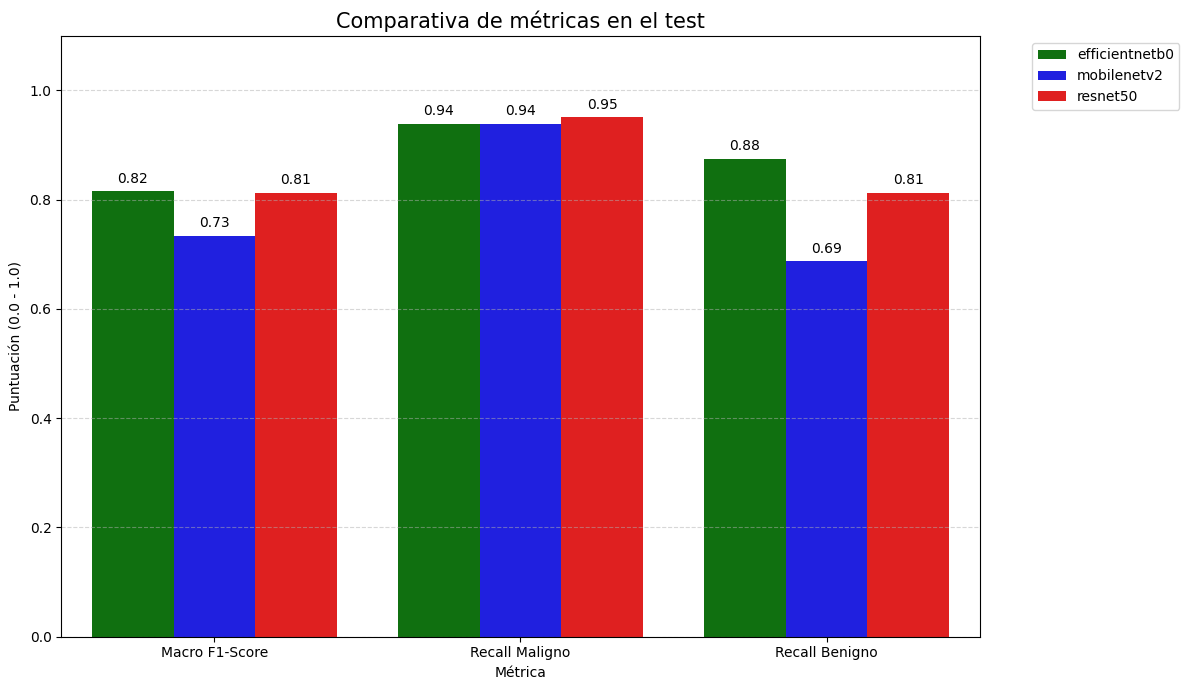

In [3]:
# Lista resultados
metrics_data = []

# Datos csv
for model in MODELS:
    folder_name = f"{model}_outputs"
    metrics_dir = os.path.join(BASE_PATH, folder_name, 'metrics')
    
    summary_path = os.path.join(metrics_dir, f"{model}_summary_metrics.csv")
    report_path = os.path.join(metrics_dir, f"{model}_classification_report.csv")
    
    # Por si fallan
    macro_f1 = 0.0
    recall_mal = 0.0
    recall_ben = 0.0
    
    # Macro f1
    if os.path.exists(summary_path):
        df_sum = pd.read_csv(summary_path)
        if 'macro_f1' in df_sum.columns:
            macro_f1 = df_sum['macro_f1'].iloc[0]
            
    # Recalls
    if os.path.exists(report_path):
        # index_col=0 para 1ª columna
        df_rep = pd.read_csv(report_path, index_col=0) 
        
        if 'malignant' in df_rep.index and 'recall' in df_rep.columns:
            recall_mal = df_rep.loc['malignant', 'recall']
            
        if 'benign' in df_rep.index and 'recall' in df_rep.columns:
            recall_ben = df_rep.loc['benign', 'recall']
            
    # Guardar datos
    metrics_data.append({
        'Modelo': model,
        'Macro F1-Score': macro_f1,
        'Recall Maligno': recall_mal,
        'Recall Benigno': recall_ben
    })

df_compare = pd.DataFrame(metrics_data)

# Reorganizar datos para barras
df_melted = df_compare.melt(id_vars='Modelo', 
                            value_vars=['Macro F1-Score', 'Recall Maligno', 'Recall Benigno'], 
                            var_name='Métrica', 
                            value_name='Valor')

# Grafica
colors = {'efficientnetb0': 'green', 'mobilenetv2': 'blue', 'resnet50': 'red'}

plt.figure(figsize=(12, 7))
sns.barplot(data=df_melted, x='Métrica', y='Valor', hue='Modelo', palette=colors)

plt.title('Comparativa de métricas en el test', fontsize=15)
plt.ylim(0, 1.1)
plt.ylabel('Puntuación (0.0 - 1.0)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Numero sobre las barras con 2 decimales
ax = plt.gca()
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.2f}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha='center', va='center', 
                   xytext=(0, 9), 
                   textcoords='offset points',
                   fontsize=10)
                   
plt.tight_layout()
plt.show()

Tal y como se estableció en la metodología, el sistema debe minimizar los falsos negativos en la detección de tumores, ya que fallar en un caso positivo es especialmente crítico en el ámbito médico.
En este sentido, la métrica de Recall Maligno muestra que tanto EfficientNetB0 como ResNet50 alcanzan un sobresaliente 0.94/0.95.

Sin embargo, EfficientNetB0 es superior gracias a su capacidad para manejar el grave desbalanceo del dataset, especialmente en la clase benigna.
Mientras que MobileNetV2 logra identificar la clase benigno con un 0.81, EfficientNetB0 tiene un rendimiento del 0.88.
Esta mejor gestión de las clases minoritarias se traduce en un Macro F1-Score de 0.82, superando a los otros dos modelos y demostrando que EfficientNetB0 aprende características discriminativas mucho más ricas y generalizables en todo el espectro pulmonar.

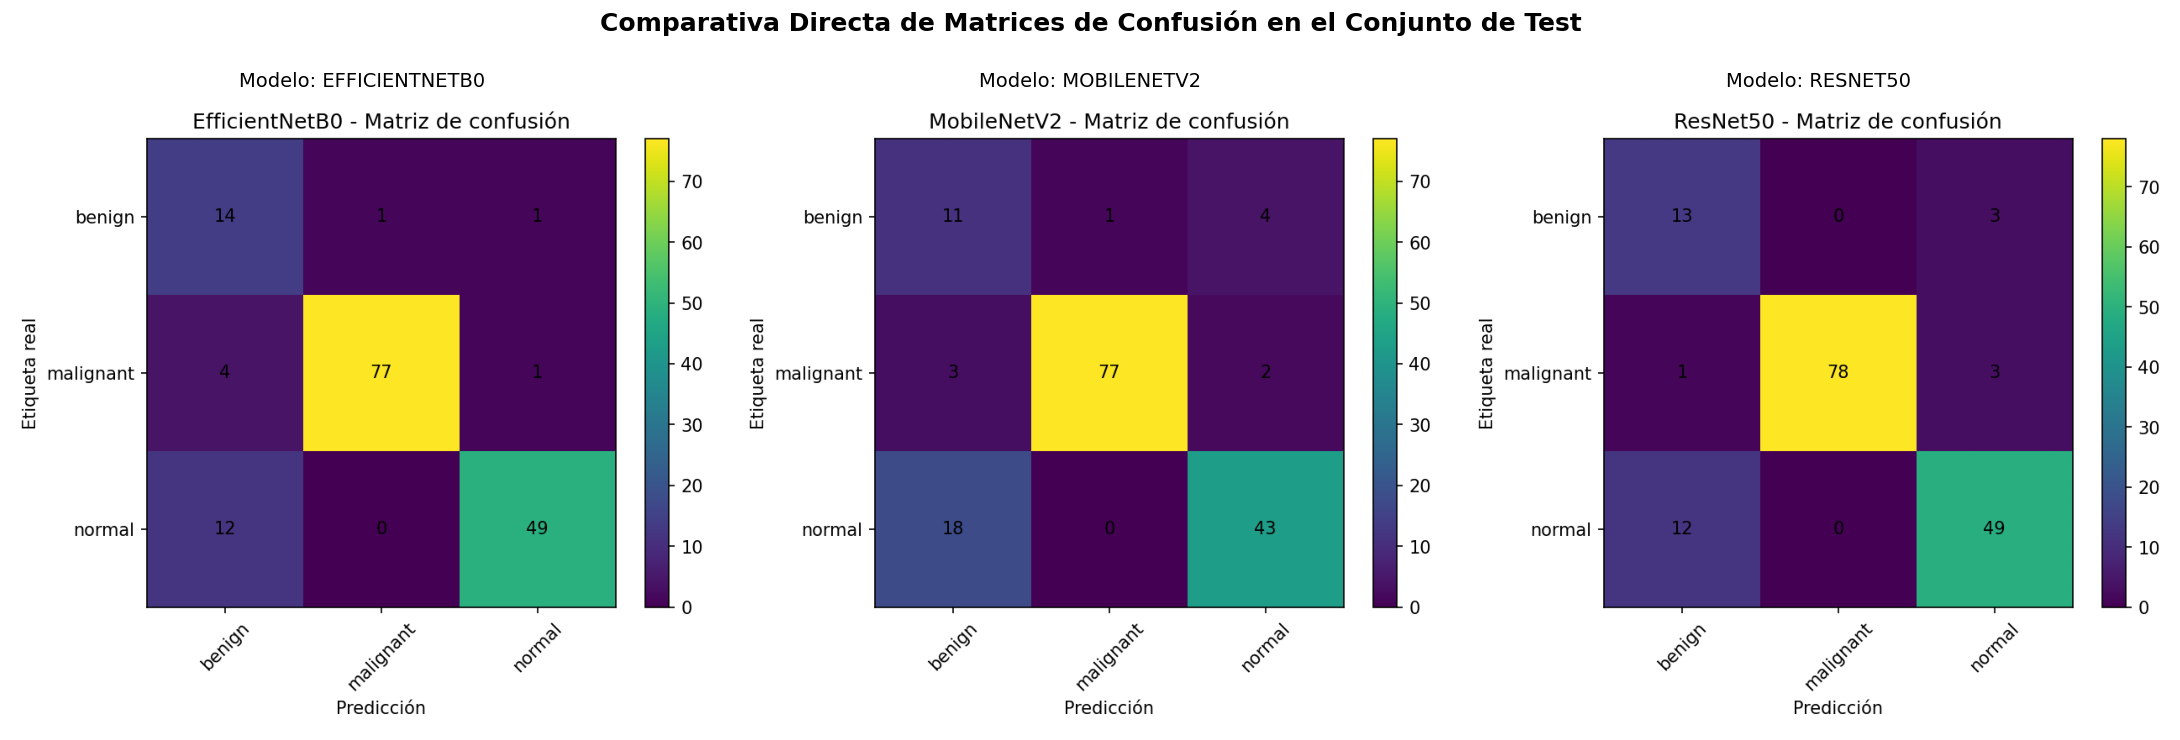

In [ ]:
# Creamos una figura con 3 subgráficos
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Comparativa Directa de Matrices de Confusión en el Conjunto de Test', fontsize=18, fontweight='bold', y=1.05)

for i, model in enumerate(MODELS):
    # NOTA: Asegúrate de que el archivo PNG se llama exactamente así en tus carpetas
    img_path = os.path.join(BASE_PATH, f"{model}_outputs", "figures", f"{model}_confusion_matrix.png")
    
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"Modelo: {model.upper()}", fontsize=14, pad=10)
        axes[i].axis('off') # Ocultamos los ejes porque la imagen ya los trae
    else:
        axes[i].text(0.5, 0.5, f"Imagen no encontrada:\n{img_path}", ha='center', va='center')
        axes[i].axis('off')

plt.tight_layout()
plt.show()

La visualización de las matrices de confusión arroja luz sobre el comportamiento real de las redes frente al desbalanceo del dataset en el conjunto de test.

* Comportamiento ante la clase "Malignant": En un contexto de diagnóstico médico de cáncer pulmonar, el error más crítico es el falso negativo en la clase maligna, es decir, predecir que un tumor es benigno o un tejido es normal cuando en realidad es cáncer. En este aspecto, los modelos muestran un rendimiento clínico excelente, logrando 77/78 aciertos. La diferencia se encuentra en los falsos negativos. EfficientNetB0 encuentra otros 4 que los clasifica como benignos ky 1 no lo encuentra; MobileNetV2 solo encuentra 3 más aunque clasificados como benignos; y ResNet50, resulta mucho menos fiable, ya que comete 3 falsos negativos en esta clase crítica.

* Comportamiento ante la clase "Benign": Aquí se observa cómo afecta el desbalanceo a cada red. MobileNetV2, a pesar de acertar en los casos malignos, sufre un claro sesgo hacia la clase mayoritaria: de los 16 casos benignos reales, falla en 5, clasificándolos erróneamente como malignos o normales. ResNet50 mejora un poco, pero sigue confundiendo los tumores benignos como normales. EfficientNetB0 logra el mejor desempeño en esta clase desbalanceada con 14 aciertos sobre 16, demostrando una extracción de características más robusta.


EfficientNetB0 es la arquitectura del pipeline que logra el mejor rendimiento global y el mayor equilibrio clínico. No solo asegura la detección de la clase maligna con una tasa de acierto casi perfecta (77/82), sino que mejora la capacidad de MobileNetV2 para detectar correctamente tumores benignos. Por todas estas razones, se consolida firmemente como el modelo elegido para avanzar a la fase de explicabilidad visual con Grad-CAM.

In [8]:
all_metrics = []

for model in MODELS:
    folder_name = f"{model}_outputs"
    summary_path = os.path.join(BASE_PATH, folder_name, 'metrics', f"{model}_summary_metrics.csv")
    
    if os.path.exists(summary_path):
        df = pd.read_csv(summary_path)
        # Añadimos el nombre del modelo al principio para identificar la fila
        df.insert(0, 'Arquitectura', model.upper()) 
        all_metrics.append(df)

if all_metrics:
    df_final = pd.concat(all_metrics, ignore_index=True)
    
    # Limpiamos la columna 'model' original si existía para no duplicar
    if 'model' in df_final.columns:
        df_final = df_final.drop(columns=['model'])
    
    # Damos formato a la tabla para que sea más visual ("más bonito y completo")
    display(df_final.style.background_gradient(cmap='Blues', subset=pd.IndexSlice[:, df_final.columns[1:]]).format(precision=4))
else:
    print("No se encontraron los archivos de resumen de métricas.")

,Arquitectura,test_loss,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,EFFICIENTNETB0,0.3291,0.8805,0.8049,0.8724,0.8154,0.9247,0.8805,0.8933
1,MOBILENETV2,0.3498,0.8239,0.7362,0.7771,0.7342,0.8804,0.8239,0.8424
2,RESNET50,0.2151,0.8805,0.7970,0.8557,0.8130,0.9078,0.8805,0.8892


* Detección de la clase maligno: Evaluando la métrica más importante para el diagnóstico médico, observamos que tanto EfficientNetB0 como MobileNetV2 logran un sobresaliente 0.8805. Esto garantiza una tasa mínima de falsos negativos. En contraste, ResNet50 presenta un rendimiento netamente inferior con un 0.8239, lo que lo descarta como una opción segura en un entorno clínico.

* Detección de la clase benigno: La diferencia definitiva entre los modelos radica en su comportamiento ante la clase más minoritaria del dataset. Mientras que MobileNetV2 fracasa en esta categoría con una puntuación de 0.7362, evidenciando que el modelo simplemente asume que casi todo es maligno. EfficientNetB0 consigue el mejor desempeño del experimento con un 0.8049. ResNet50 se queda en un punto intermedio con un 0.7970.

* Rendimiento Global (Macro F1-Score): La métrica Macro F1-Score promedia el rendimiento de todas las clases otorgándoles el mismo peso, por lo que penaliza severamente a los modelos que ignoran las clases minoritarias. En este indicador global, EfficientNetB0 domina con un 0.8154, superando con un amplio margen el 0.7342 de MobileNetV2 y por poco a ResNet50, que tiene un 0.8130. 

Los números respaldan rotundamente la elección de EfficientNetB0. Es la única arquitectura capaz de mantener la altísima sensibilidad requerida para detectar tumores malignos, al mismo tiempo que extrae los patrones necesarios para identificar los tejidos benignos mejor que cualquier otra red evaluada.

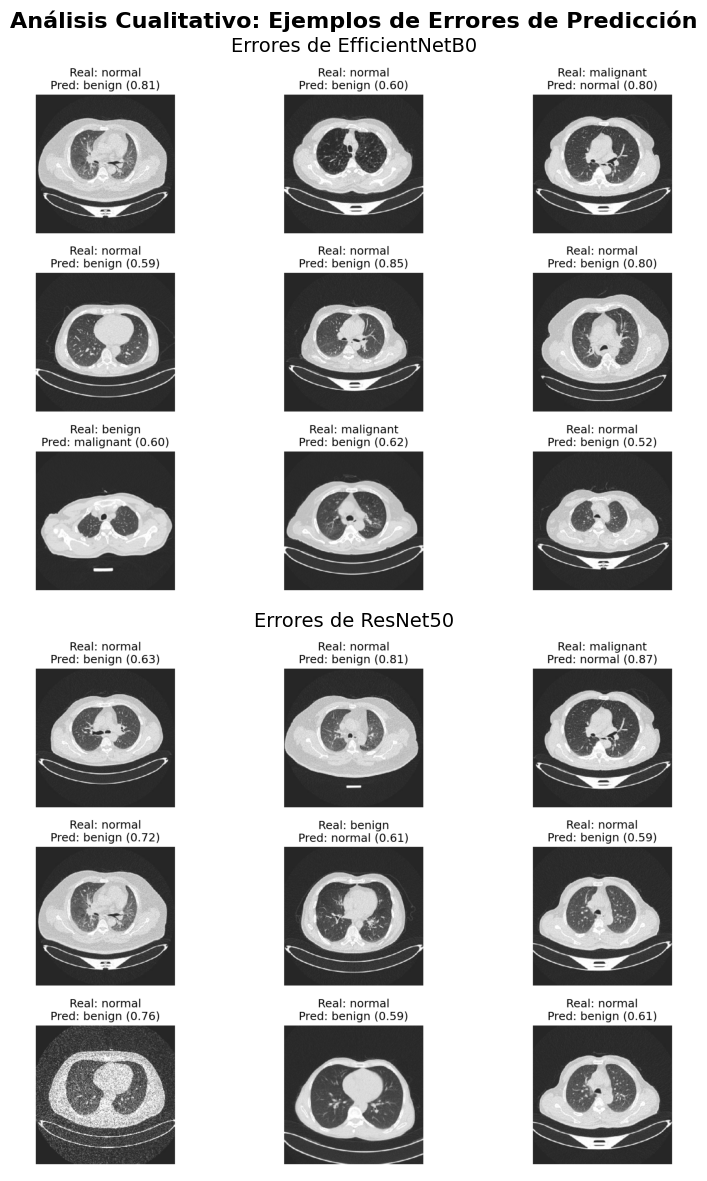

In [9]:
BASE_PATH = os.path.join('..', 'outputs')

# Imagenes
img_eff_path = os.path.join(BASE_PATH, "efficientnetb0_outputs", "figures", "efficientnetb0_error_examples.png")
img_res_path = os.path.join(BASE_PATH, "resnet50_outputs", "figures", "resnet50_error_examples.png")

fig, axes = plt.subplots(2, 1, figsize=(18, 12))
fig.suptitle('Análisis Cualitativo: Ejemplos de Errores de Predicción', fontsize=16, fontweight='bold')

# EfficientNetB0
if os.path.exists(img_eff_path):
    img_eff = mpimg.imread(img_eff_path)
    axes[0].imshow(img_eff)
    axes[0].set_title("Errores de EfficientNetB0", fontsize=14)
    axes[0].axis('off')
else:
    axes[0].text(0.5, 0.5, f"Imagen no encontrada:\n{img_eff_path}", ha='center', va='center')
    axes[0].axis('off')

# ResNet50
if os.path.exists(img_res_path):
    img_res = mpimg.imread(img_res_path)
    axes[1].imshow(img_res)
    axes[1].set_title("Errores de ResNet50", fontsize=14)
    axes[1].axis('off')
else:
    axes[1].text(0.5, 0.5, f"Imagen no encontrada:\n{img_res_path}", ha='center', va='center')
    axes[1].axis('off')

plt.tight_layout()
plt.show()

Más allá de las métricas numéricas y las matrices de confusión, la visualización directa de los mapas de atención de las redes confirma que EfficientNetB0 es el modelo más fiable desde un punto de vista clínico. Esta comparativa visual es crucial, pues revela dónde está mirando la red neuronal para tomar su decisión.

Al observar la imagen de EfficientNetB0, los ejemplos mostrados demuestran una precisión visual sobresaliente. En los casos etiquetados correctamente como "Normal", el mapa de calor es difuso y cubre el fondo, indicando correctamente que la red no encuentra ningún foco de patología en el parénquima pulmonar.
En los ejemplos "Malignant" logra una retención casi perfecta: el mapa de calor aísla e ilumina de forma precisa la ubicación física del nódulo tumoral visible en la tomografía original. Esto demuestra que el modelo ha aprendido a reconocer las características patológicas reales de los tumores, no solo a correlacionar ruido estadístico.


Por otra parte, en la imagen de ResNet50, presenta un contraste alarmante que lo descalifica para este pipeline. Sus mapas de calor revelan un "colapso de atención" o confusión sistemática. El modelo falla en la localización. En los ejemplos mostrados de errores, un pulmón "Normal" es clasificado como "Malignant". El mapa de calor revela que la red está prestando atención a estructuras completamente irrelevantes como el borde de la pleura o la pared torácica, confundiendo ruido anatómico con un tumor. En otros casos de tumor benigno, el modelo falla y clasifica como "Normal", simplemente porque su red de atención ignora la zona relevante y mira hacia zonas vacías o difusas.


EfficientNetB0 no solo acierta más, sino que acierta por las razones correctas, demostrando que entiende la anatomía y la patología tumoral. ResNet50, en cambio, toma decisiones basadas en el ruido visual del fondo y estructuras externas, lo que lo convierte en un modelo inseguro y no confiable para un entorno médico real. Esta evidencia visual valida definitivamente nuestra elección de EfficientNetB0 para avanzar a la fase final de explicabilidad con Grad-CAM.